# Pandas - Explode
___
- EG: `df.explode('job_skills')`
- We spent the entire last lesson working through and understanding how to clean up the `job_skills` Column and Convert it into a List
- It was a lot of work, but it will pay off, because now, we are going to get into Visualizing it and actually being able to see, what are the Top Skills for a Data Analyst
- In order to do this, we will need to use the `.explode()` Method on the `job_skills` Column in order to clean it up a little further

- Why are we learning about the `.explode()` Method?
    - well let's look at a fake Example using Fake Data

In [75]:
# Simple Example with fake Data to learn about .explode()
import pandas as pd

# Set up the Data we will be using
data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

# Create the DataFrame and Assign it a Variable
df_skill_list = pd.DataFrame(data)

# Print the DataFrame
df_skill_list

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


- We have a DataFrame with a few Jobs and then a List of Skills that each Job requires
- If we wanted to Count up the number of times, Excel or Python appears it's going to be a little bit difficult in this Format

In [76]:
# Trying to Run Value Counts on job_skills
df_skill_list.value_counts('job_skills')

TypeError: unhashable type: 'list'

- We would get a TypeError because List is not Hashable in order to do this...
- You could do it via a Loop/List Comprehension maybe... and Loop through each of the Rows of the Data Set and then Aggreate what Skills are inside each Job Posting
    - Then from there, make a Total Column, thjat can do Totals for each of those Skills (not going to Copy out the Code because it's not Valuable)
    - To do this, it Required 5 Lines of Code and that's a bit much to achieve something like this...
- Instead, what we can do with the DataFrame, when we call it, Run the `.explode()` Method on it
    - Specifying the `job_skills` Column, and Running it Yields...

In [ ]:
# Running .explode
df_skill_list.explode('job_skills')

,job_title_short,job_skills
0,Data Analyst,excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


- THis Function, Explodes the Data out where every single Value from that List is it's own individual Row
- So now, we have 3 Data Analyst Rows (3 Skills), 2 Data Scientist Rows (2 Skills) and 3 Data Engineer Rows (3 Skills)
- In this Type of Format it makes it really easy to Run the `value_count` Method on the `job_skills` Column
    - As now, we can get a Quick Count of how many Skills each of these things has

In [ ]:
# Assing a value_counts onto the explode
df_skill_list.explode('job_skills').value_counts('job_skills')

job_skills
python     3
excel      1
sql        1
r          1
aws        1
airflow    1
Name: count, dtype: int64

- We can even take it a Step further and Plot it as well on a Bar Chart
- Which shows the Counts of all the different Skills

<Axes: xlabel='job_skills'>

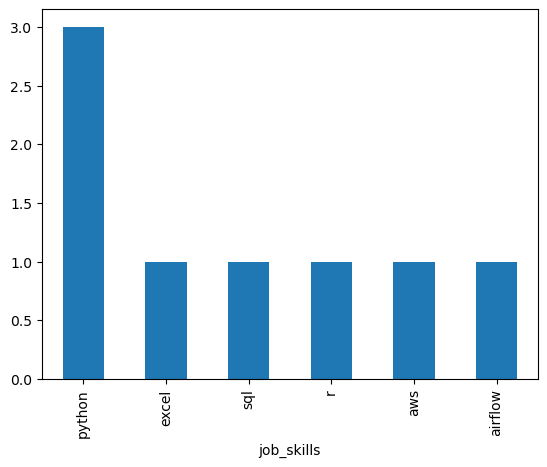

In [ ]:
# Plotting the Data
df_skill_list.explode('job_skills').value_counts('job_skills').plot(kind='bar')

- Now to start on an Example using the Data that we have been working on throughout this course, our Job Posting Data
- Doing the usual of the Imports, Loading the Data and Cleaning the Data
    - But additionally, for the Cleaning Data, adding in an extra line for cleaning up the `job_skills` using the `.apply()` Method to clean the Skill List into a List Data Type that we worked on in the last section

In [ ]:
# Imports
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading the Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleaning the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

In [ ]:
# Printing out the DataFrame
df[['job_title_short', 'job_skills']].head()

,job_title_short,job_skills
0,Senior Data Engineer,NaN
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


- Time to start Exploding out the `job_skills` Column using the `.explode()` Method
- Above we can see the first 5 Records of the DataFrame, Filtered down by `job_skills` along with it's corresponding `job_title`
    - Going to Run `.explode()` Method on the Column of `job_skills`
    - Time to Run the `help()` Function on the `.explode()` Method to understand better what it needs

In [ ]:
help(df.explode)

Help on method explode in module pandas.core.frame:

explode(column: 'IndexLabel', ignore_index: 'bool' = False) -> 'DataFrame' method of pandas.DataFrame instance
    Transform each element of a list-like to a row, replicating index values.
    
    Parameters
    ----------
    column : IndexLabel
        Column(s) to explode.
        For multiple columns, specify a non-empty list with each element
        be str or tuple, and all specified columns their list-like data
        on same row of the frame must have matching length.
    
    ignore_index : bool, default False
        If True, the resulting index will be labeled 0, 1, …, n - 1.
    
    Returns
    -------
    DataFrame
        Exploded lists to rows of the subset columns;
        index will be duplicated for these rows.
    
    Raises
    ------
    ValueError :
        * If columns of the frame are not unique.
        * If specified columns to explode is empty list.
        * If specified columns to explode have not mat

- `df.explode()`
    - Takes 2 Parameters
        - **Column**: Transforms each element of a List-like to a Row, replicating Index Values
        - **Ignore_index**: 

In [ ]:
# Running the Explode Method with just providing the Column Name of job_skills
df.explode('job_skills')

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


- Looking at the Index and also the Rows, we can see that they are now Duplicated
- Scrolling over to the `job_skills` Column, we can see that it's broken out into Individual Rows for each Skill
- We will want to Assign this to a New DataFrame to keep the Integrity of the Original
    - Assigning it to `df_exploded` and also Creating a Copy as well

In [ ]:
# Assigning it to a Variable
df_exploded = df.explode('job_skills')

# Printing out to Verify
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


- Inspecting it, everything looks good
- Time to Visualize the `job_skills` Column!
    - Since now we have all of the Skills Individually, we can do a `value_counts()` on the `job_skills` Column to find the Top 10 Skills!

<Axes: xlabel='job_skills'>

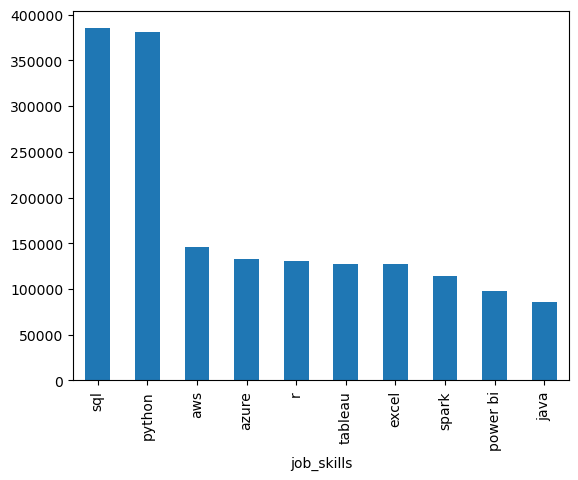

In [ ]:
# Visualizing the job_skills Column using value_counts
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')

- We get back a Bar Chart showing the Top 10 Skills Visualized by their associated Counts for each Job Title!
- Now, let's go futher, right now, we are looking at all the Job Titles... now we can Group them not only by their Skill Count but also by their `job_title_short`
    - That way we can then pick out Job Titles individually and look at them eg: Only look at Data Analyst, Data Engineer or Data Scientist
- For this, we will go back to the original Variable that we had of `df_exploded` and Build off of that
- We not only want to Group By the `job_title_short` but also the `job_skills`
    - Start by calling out our Variable `df_exploded`
    - Using the `.groupby()` Method
    - Inside as the Arguments, we will Provide the List of Columns we want to `groupby` which are: `['job_title_short', 'job_skills']`
    - Then getting to the Aggregation Function, we want a Count of all these. To do that we will need to use `.size()`

In [ ]:
# Grouping by the job title and the job skills
df_exploded.groupby(['job_title_short', 'job_skills']).size()

job_title_short    job_skills
Business Analyst   airflow        318
                   airtable        17
                   alteryx       1078
                   angular         87
                   ansible        120
                                 ... 
Software Engineer  wrike            4
                   wsl             13
                   xamarin         35
                   yarn           145
                   zoom           229
Length: 2256, dtype: int64

- We are getting back the Total Count for each Skill, broken down by Job Title
    - Grouped By the Job Titles, and Counting each instance of the different Skills where it appears for each one of those different Job Titles
    - Having `job_title_short` on the left and broken up by all the `job_skills` associated with each `job_title_short`
- We then Assign it to the Variable of `skills_count` and if we look at the `type()` of the Variable we just Created...
    - It comes back as a Series
    - Series aren't bad to work with when it comes to Plotting but it's good practice to work with DataFrames
    - So we are going to Convert this into a DataFrame

In [ ]:
# Assigning the GroupBy to a Variable
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

# Running the Type on the Variable
type(skills_count)

pandas.Series

- Creating a New Variable called `df_skills_count`
- Set it Equal to `skills_count`
- In order to Transform it into a DataFrame, we need to use `reset_index()`
- We will need to give the Index/Count Column a Title/Name as well
    - Because right now, we are Returning 3 Columns, the `job_title_short`, `job_skills` and the counts of those Skills but it doesn't have a Title/Column Name
    - Running the `reset_index()` without a Name, would assign the Count Column a Title of 0, which isn't right...
    - So we will have to Change that and Assign a Title to it by specifying a name to it, otherwise, it will give it a Default Title of 0
- We will name it `skill_count` by doing `name='skill_count`
- Running this, we can see, the Index has now been Added Successfully, and the specified Title has been given to our Aggregated Column

In [ ]:
# Converting the Series into a DataFrame by resetting the Index and naming our aggregated Column
df_skills_count = skills_count.reset_index(name='skill_count')

# Printing out the Results to Inspect our New DataFrame
df_skills_count

,job_title_short,job_skills,skill_count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120
...,...,...,...
2251,Software Engineer,wrike,4
2252,Software Engineer,wsl,13
2253,Software Engineer,xamarin,35
2254,Software Engineer,yarn,145


- Now that we have all that done
    - Next thing to do, is to Sort these Values!
    - We will want to Sort the Values by `skill_count` is going to be necessary
    - Because when we want to Visualize it and only show the Top 10 Results, we can just invoke the `head()` Method to do that and pull out the Top 10
- Once again we define our Variable of `df_skills_count` and set it Equal to itself so it overrides itself
    - Like this: `df_skills_count = df_skills_count`
    - Now we need to Sort these Values so we use the `.sort_values()` Method 
    - Inside of there, we put in the Column that we want to Sort this by... so we use the `skill_count` Column! - `by='skill_count`
    - We now need to set it to Sort by Descending Order since the Default is Ascending Order, all we need is `ascending=False`
- Now we have it in the correct order, going from Highest to Lowest

In [ ]:
# Sorting the Values
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)

# Printing out the Results to Inspect our Sorted Values
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
776,Data Engineer,linode,1
1843,Senior Data Scientist,delphi,1
1888,Senior Data Scientist,kali,1
1289,Machine Learning Engineer,powerbi,1


- Now we have what we need in order to Plot!
    - We are going to go and Plot the Top 10 Skills for Data Analyst
- To do this:
    - Create an Individual Variable for the Job Title, this is because if we want to change it later and look at another Job, we make it easier
    - Call it `job_title` and have it Equal `Data Analyst`
    - Create a New Variable called `top_skills` and set that Equal to `10` as we only want the Top 10 Skills back, again making a Variable makes it easier to change later on if we want something different
    - We then make a new DataFrame Variable called `df_skill_final` and Set it equal to the Filtered Data Frame Sorted in Descending Order that we made earlier called `df_skills_count`
    - Then Filter it down by the `job_title_short` Column by doing `[df_skills_count['job_title_short']]`
        - We do this because we only want back the associated Skills and their respective Counts that will match the Job Title in the Variable we are Passing in via `job_title` 
    - We want to make sure it's Equal to the Value stored in the `job_title` Variable we Created so we do a comparison with it by doing `== job_title`
    - We then only want to get the Top 10, we ofc need to Run the `head()` Method, passing in the Variable of `top_skills`
- Printing that out below to Inspect it and see what we get back and how it looks


In [93]:
# Creating Variables
job_title = 'Data Analyst'
top_skills = 10

# Creating our New DataFrame and Setting it Equal to our Filtered one and Filtering it down to what we need
df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

# Printing out the DataFrame to inspect it and make sure we get back what we wanted
df_skill_final

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


- Now we get back, only for **Data Analyst**, the Top 10 Skills in Descending order and their Associated Counts!
- Because we have this, we can Plot it as it's something we can Plot easily
    - We Run the `.plot()` Method on our `df_skill_final` DataFrame
    - Specifying the kind as Horizontal Bar Chart. Doing this by saying `kind='barh`
    - Because this DataFrame has multiple different Columns in it, we need to specify the X and Y Values
        - `x='job_skills` and `y='skill_count'`

<Axes: ylabel='job_skills'>

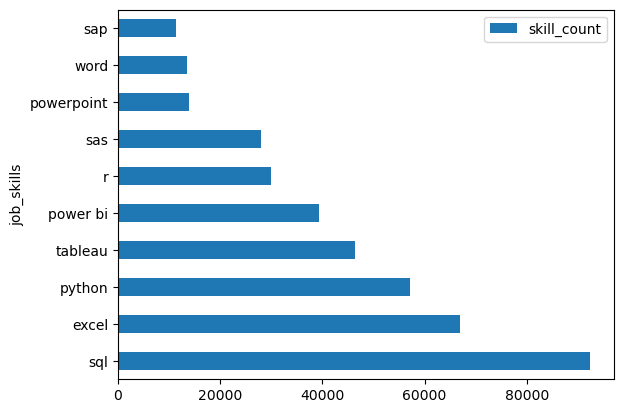

In [94]:
# Plotting the Data into a Graph
df_skill_final.plot(kind='barh', x='job_skills', y='skill_count')

- Looking at the Graph, we only have 1 Problem left to Solve. It's Printing it in Ascending Order
- Because these Horizontal Bar Charts start Plotting from the Bottom Left Hand Corner, and work their way up from there
    - We will want it in Descending Order
- To fix this we need to use a New Matplotlib Method we haven't used before and that is:
    - `matplotlib.axes.Axes.invert_yaxis()`
    - This Method inverts the Y Axis
    - The one learning point we have to go through with this Method is, that it's Run on the Axes
        - Which in order to get the Axes, we will need to Run another Method! Which is:
        - `matplotlib.pyplot.gca()`
            -  This Method, gets the current Axes. (gca means Get Current Axes)
            - We will learn more about this Method and the Invert Y Axis Method later but it's good to get introduced to it now and get some exposure to it and how it works
        - For now, all we need to Understand is, it's going to get the Axes and we are going to Invert the Axis
- We call the Pyplot Module with the Alias of `plt`
    - We are going to Run the `.gca()` Method on it
    - Then we will Run, on that, the `.invert_yaxis()` Method
- While we are at it, we might as well add some Cleanup on this as well to make it nice and presentable!
    - Let's Add a Title using an `f string`, with this we specify:
        - The Top Skills amount we are Displaying by referencing the `top_skills` Variable in the `F String`
        - The Job Title we are Displaying this Graph for by also referencing the `job_title` Variable in the `F String`
    - This makes it super Dynamic and the Graph Title, will Update whenever these Variable's are changed to Display different information
        - Makes it so we only have to change the information in 1 place, rather changing it in multiple places 
        - The Notation is `plt.title(f'Top {top_skills} Skills for {job_title}s')`
    - Change the X Label and Update it to **Job Posting Count**
        - We do this by `plt.xlabel('Job Posting Count')`
    - Remove the Y Label as it's not needed since the Title explains what's going on well enough so we are just going to leave this as Blank
    - Last thing to Notice is the Legend down the bottom, it's pretty redundent as the Graph is self explanitory so we are just going to Remove it
        - To do this, we access it by using `plt.legend()` and it has a Method attached to it called `set_visible()`. In here we Set a Boolean Value, by Default it's True, so we Pass in False
        - Adding this in, makes it go away
    - And ofc, the last thing to add in is the `plt.show()` as we don't want that Memory Location Displaying

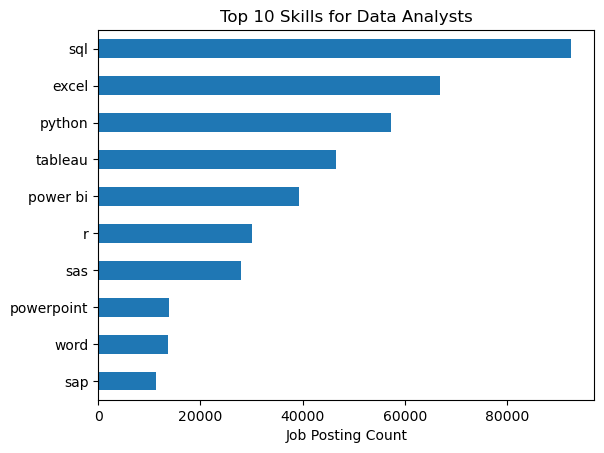

In [101]:
# Running the plot on the DataFrame again
df_skill_final.plot(kind='barh', x='job_skills', y='skill_count')

# Running those 2 Methods alongside our Visualization
plt.gca().invert_yaxis()
# Adding our Visualization Cleanup
plt.title(f'Top {top_skills} Skills for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()

- As we can see, they worked! The Axis is now Inverted
- And now, with how we Build this, we can go in and look at other Job Titles as well!
    - All we need to do, is change the Value in the `job_title` Variable
- That's the amazing thing about Python, you can make something programatically changeable
- If we want to look at Data Engineer's, all we need to do is change the Value inside the `job_title` from 'Data Analyst' to 'Data Engineer'
- We can also change the amount of Results we get back as well!
    - By changing the Value in the `top_skills` Variable, we can get back the Top 15 Skills for a Job by Updating the 10 to 15, or changing it to whatever Value we want